# 1 Imports

In [24]:
import joblib
import pandas as pd
import sys
from pathlib import Path
import torch
import os
import funciones

import importlib

In [ ]:
importlib.reload(funciones)

# Audio de entrada

In [2]:
audios = []

audio_español_generado = os.path.join(os.getcwd(),"audios_prueba_pipeline//español_generado.wav")
audios.append(audio_español_generado)
audio_español_real = os.path.join(os.getcwd(),"audios_prueba_pipeline//español_real.wav")
audios.append(audio_español_real)
audio_ingles_generado = os.path.join(os.getcwd(),"audios_prueba_pipeline//ingles_generado.wav")
audios.append(audio_ingles_generado)
audio_ingles_real = os.path.join(os.getcwd(),"audios_prueba_pipeline//ingles_natural.wav")
audios.append(audio_ingles_real)

## Extraer características

In [3]:
a1 = funciones.extract_features(audio_español_generado)
a2 = funciones.extract_features(audio_español_real)
a3 = funciones.extract_features(audio_ingles_generado)
a4 = funciones.extract_features(audio_ingles_real)

In [4]:
def dict2df(d: dict):
    claves = [c for c in d.keys() if c.startswith('mfcc') and not c.endswith('mean')]
    claves.extend(['f1', 'f2', 'f3', 'pitch'])
    for c in claves: 
        if c in d: d.pop(c)
    return pd.DataFrame(d, index=[0])

In [35]:
dfa1 = dict2df(a1)
dfa2 = dict2df(a2)
dfa3 = dict2df(a3)
dfa4 = dict2df(a4)

df_esp = pd.concat([dfa1, dfa2])
df_eng = pd.concat([dfa3, dfa4])
df_completo = pd.concat([dfa1, dfa2, dfa3, dfa4])

In [36]:
df_esp.drop(columns="filename", axis=1, inplace=True)
df_eng.drop(columns="filename", axis=1, inplace=True)
df_completo.drop(columns="filename", axis=1, inplace=True)

## Extraer gráficas

# Cargar modelos

In [7]:
modelo_rf = joblib.load('Jorge/modelo_Random_Forest.pkl')
modelo_lgbm = joblib.load('Jorge/modelo_LightGBM.pkl')
modelo_svm = joblib.load('Jorge/modelo_SVM.pkl')

In [ ]:
modelo_knn = joblib.load('Rafa/modelo_knn.pkl')
modelo_lr = joblib.load('Rafa/modelo_lr.pkl')
scaler_knn = joblib.load('Rafa/scaler_knn.pkl')
scaler_lr = joblib.load('Rafa/scaler_lr.pkl')

## Cargar datos de entrenamiento

In [30]:
X_train = pd.read_csv('datos_entrenamiento.csv')

y_train = X_train['label']
X_train.drop(columns="label", inplace = True)

# Random Forest

## Generar predicciones

In [18]:
y_pred_rf = modelo_rf.predict(df_esp)
y_pred_proba_rf = modelo_rf.predict_proba(df_esp)[:, 1]

In [40]:
print(y_pred_rf)
print(y_pred_proba_rf)

[0 1]
[0.24 0.69]


## Generar explicaciones

### SHAP

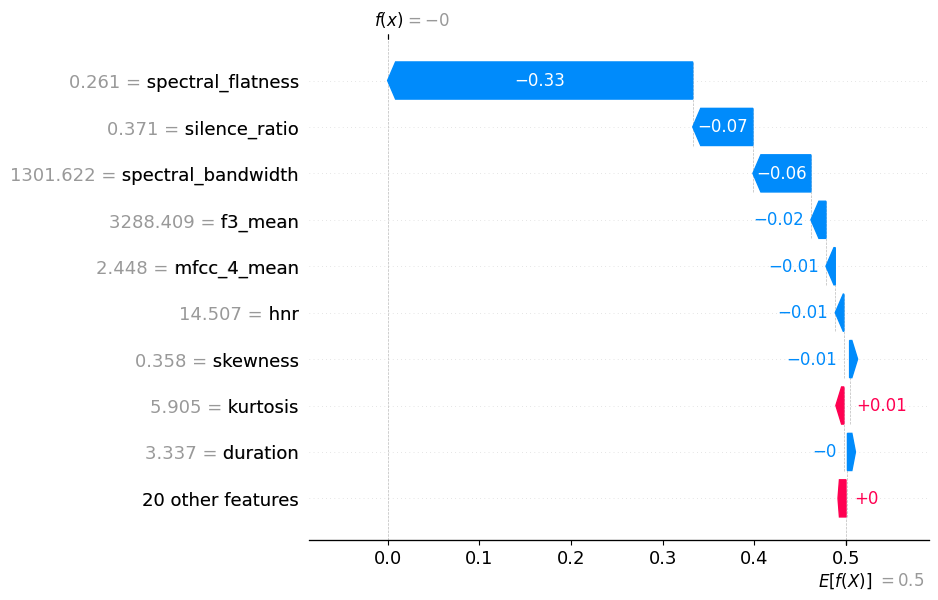

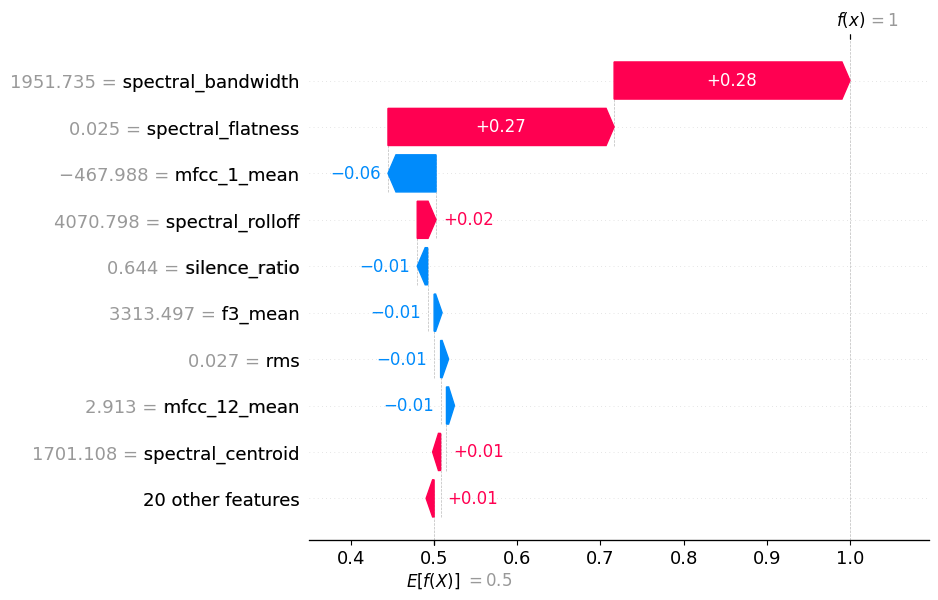

In [23]:
funciones.explica_shap(modelo=modelo_rf, X_train=X_train, X_test=df_esp, n_show=2, local=True)

### SHAP con audios en inglés

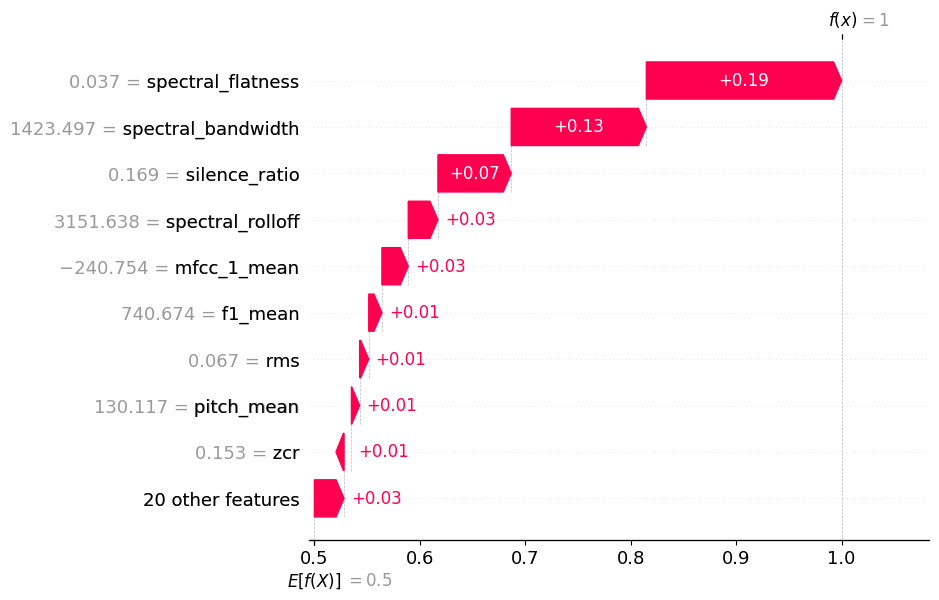

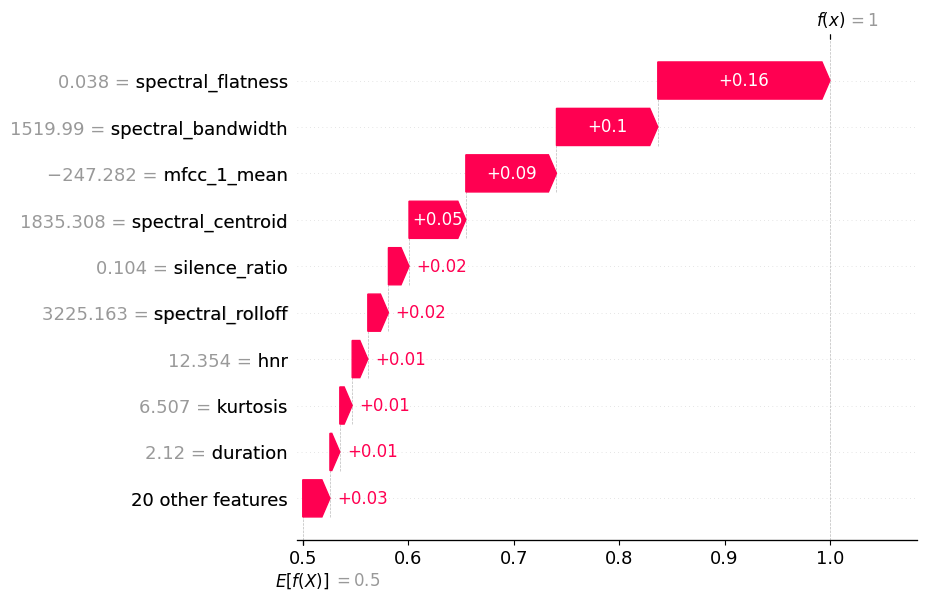

In [39]:
funciones.explica_shap(modelo=modelo_rf, X_train=X_train, X_test=df_eng, n_show=2, local=True)

### SHAP global

c:\Users\Jorge\Documents\Proyectos de programación\TFG\Modelos\funciones.py:152: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test)


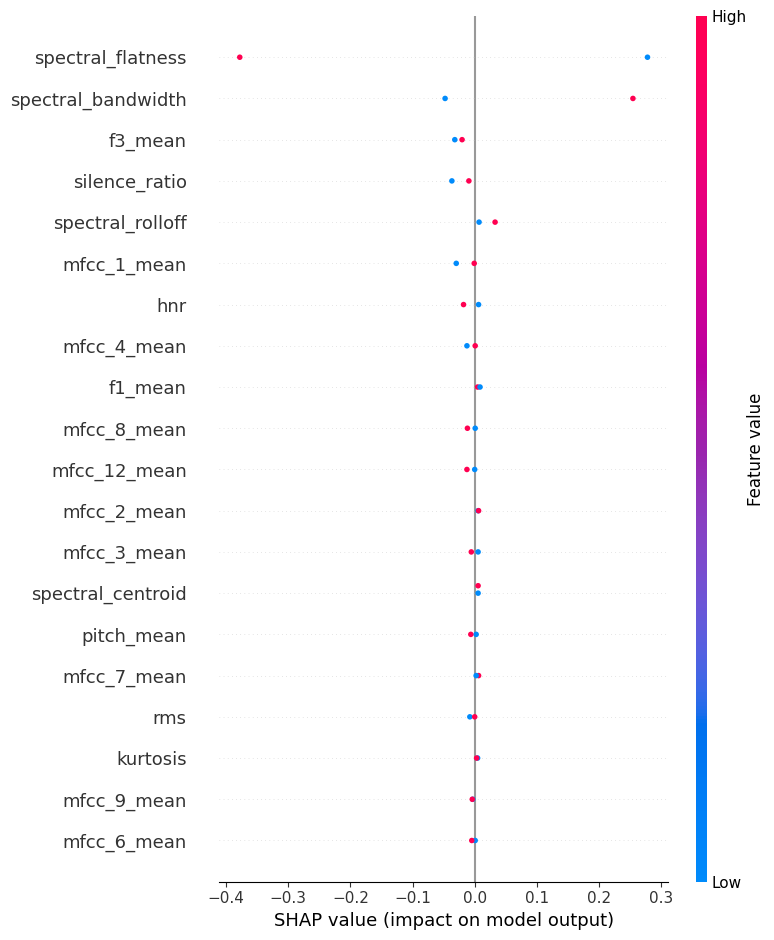

In [27]:
funciones.explica_shap(modelo=modelo_rf, X_train=X_train, X_test=df_esp, n_show=2, local=False)

### LIME

In [43]:
html = funciones.explica_lime(modelo=modelo_rf, columnas=X_train.columns, X_train=X_train, X_test=df_esp)

display(html)

c:\Users\Jorge\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


### DiCE

In [32]:
funciones.explica_dice(modelo=modelo_rf, X_train=X_train, y_train=y_train, X_test=df_esp, escalar=True)

100%|██████████| 1/1 [00:00<00:00,  3.99it/s]

Query instance (original outcome : 0)


,duration,rms,zcr,spectral_centroid,spectral_bandwidth,spectral_rolloff,spectral_flatness,pitch_mean,pitch_std,f1_mean,...,mfcc_7_mean,mfcc_8_mean,mfcc_9_mean,mfcc_10_mean,mfcc_11_mean,mfcc_12_mean,mfcc_13_mean,skewness,kurtosis,label
0,-0.338187,0.774856,0.936326,1.220188,-0.156768,0.6931,3.301198,1.698028,1.4781,1.107746,...,0.090393,-0.918376,0.319119,0.786554,-0.649153,-0.954485,1.00121,1.320745,0.857855,0



Diverse Counterfactual set (new outcome: 1)


,duration,rms,zcr,spectral_centroid,spectral_bandwidth,spectral_rolloff,spectral_flatness,pitch_mean,pitch_std,f1_mean,...,mfcc_7_mean,mfcc_8_mean,mfcc_9_mean,mfcc_10_mean,mfcc_11_mean,mfcc_12_mean,mfcc_13_mean,skewness,kurtosis,label
0,-,-,-,-,-,-,-0.8735010287,-,-,-,...,-,-,-,-,-,-,-,-,-,1.0
1,-,-,-,-,-,-,-0.0186059268,-,-,-,...,-,-,-,-,-,-,-,-,-,1.0
2,-,-,-,-,-,-,-0.0915585098,-,-,-,...,-,-,-,-,-,-2.397934943,-,-,-,1.0


# LightGBM

## Generar predicciones

In [41]:
y_pred_lgbm = modelo_lgbm.predict(df_esp)
y_pred_proba_lgbm = modelo_lgbm.predict_proba(df_esp)[:, 1]

In [42]:
print(y_pred_lgbm)
print(y_pred_proba_lgbm)

[0 1]
[0.04762321 0.91752826]


## Generar explicaciones

### SHAP

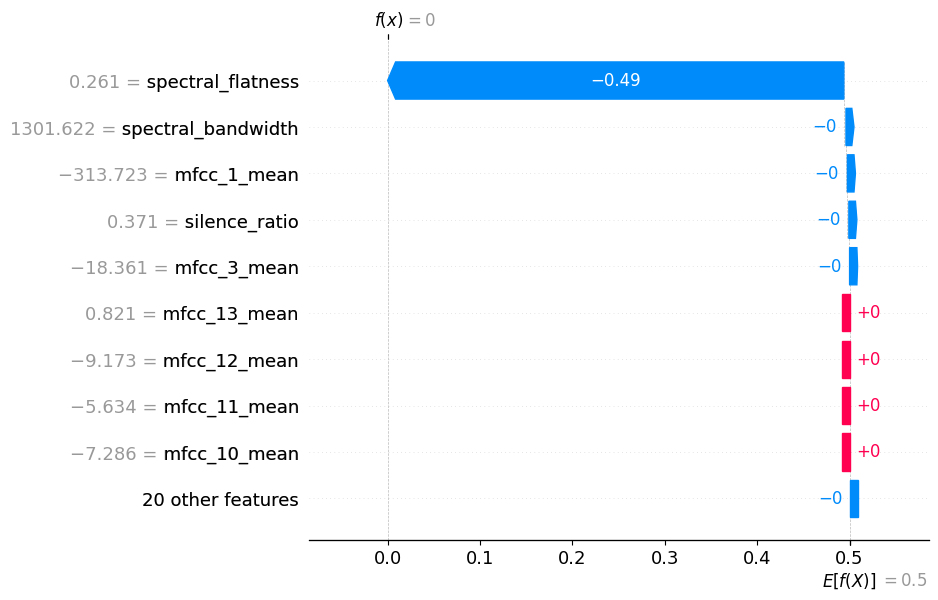

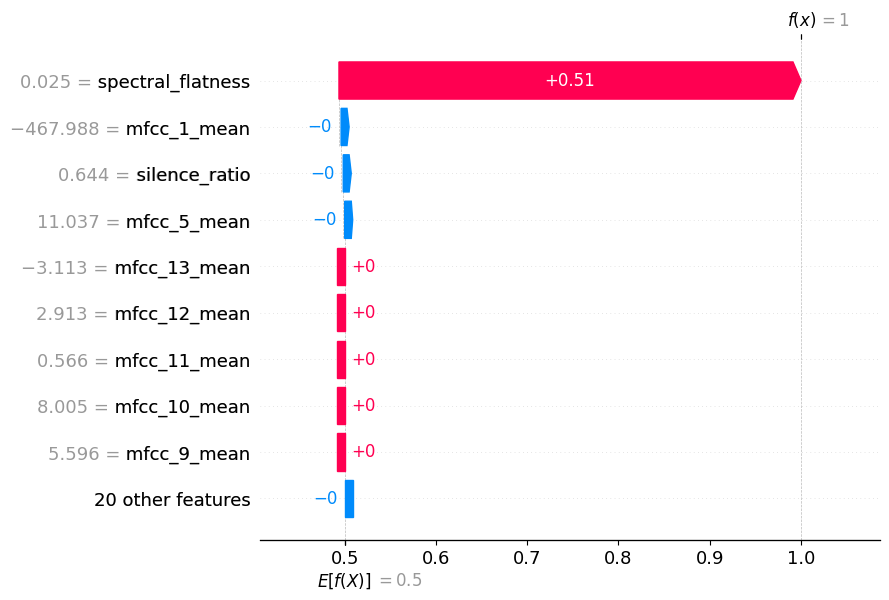

In [46]:
funciones.explica_shap(modelo=modelo_lgbm, X_train=X_train, X_test=df_esp, n_show=2, local=True)

### SHAP con audios en inglés

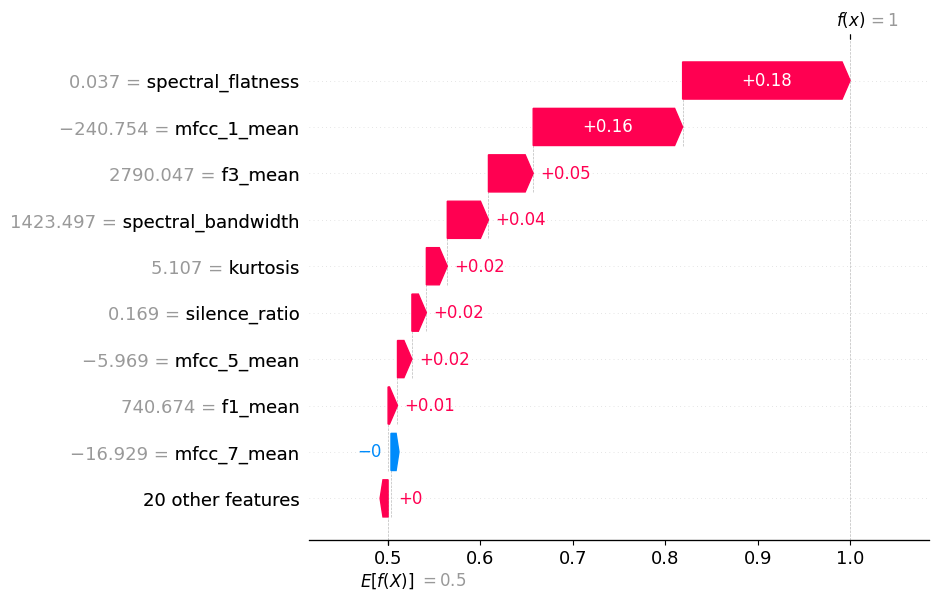

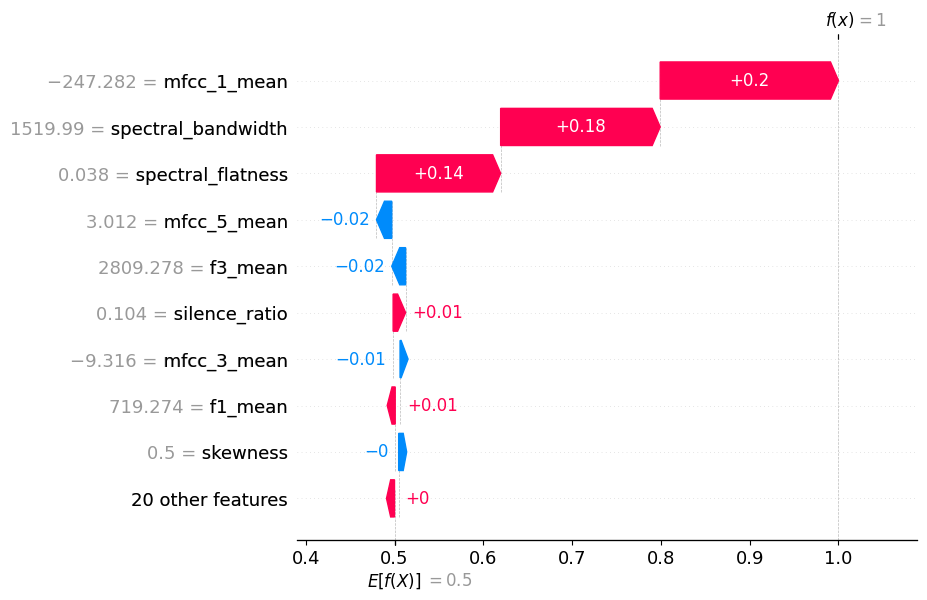

In [47]:
funciones.explica_shap(modelo=modelo_lgbm, X_train=X_train, X_test=df_eng, n_show=2, local=True)

### LIME

In [48]:
html = funciones.explica_lime(modelo=modelo_lgbm, columnas=X_train.columns, X_train=X_train, X_test=df_esp)

display(html)

c:\Users\Jorge\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


### DiCE

In [49]:
funciones.explica_dice(modelo=modelo_lgbm, X_train=X_train, y_train=y_train, X_test=df_esp, escalar=True)

100%|██████████| 1/1 [00:00<00:00,  3.72it/s]

Query instance (original outcome : 0)


,duration,rms,zcr,spectral_centroid,spectral_bandwidth,spectral_rolloff,spectral_flatness,pitch_mean,pitch_std,f1_mean,...,mfcc_7_mean,mfcc_8_mean,mfcc_9_mean,mfcc_10_mean,mfcc_11_mean,mfcc_12_mean,mfcc_13_mean,skewness,kurtosis,label
0,-0.338187,0.774856,0.936326,1.220188,-0.156768,0.6931,3.301198,1.698028,1.4781,1.107746,...,0.090393,-0.918376,0.319119,0.786554,-0.649153,-0.954485,1.00121,1.320745,0.857855,0



Diverse Counterfactual set (new outcome: 1)


,duration,rms,zcr,spectral_centroid,spectral_bandwidth,spectral_rolloff,spectral_flatness,pitch_mean,pitch_std,f1_mean,...,mfcc_7_mean,mfcc_8_mean,mfcc_9_mean,mfcc_10_mean,mfcc_11_mean,mfcc_12_mean,mfcc_13_mean,skewness,kurtosis,label
0,-,-,-,-,-,-,-0.2388582905,-,-,-,...,-,-,-,-,-,-,-,-,-,1.0
1,-,-,-,-,-,-,-0.7772022448,-,-,-,...,-,-,-,-,-,-,-,-,-,1.0
2,-,-,-,-,-,-,-0.7513872066,-,-,-,...,-,-,-,-,-,-,-,-,-,1.0


# Support Vector Machine

## Generar predicciones

In [44]:
y_pred_svm = modelo_svm.predict(df_esp)
y_pred_proba_svm = modelo_svm.predict_proba(df_esp)[:, 1]

In [45]:
print(y_pred_svm)
print(y_pred_proba_svm)

[0 1]
[0.01509657 0.8575901 ]


## Generar explicaciones

### SHAP

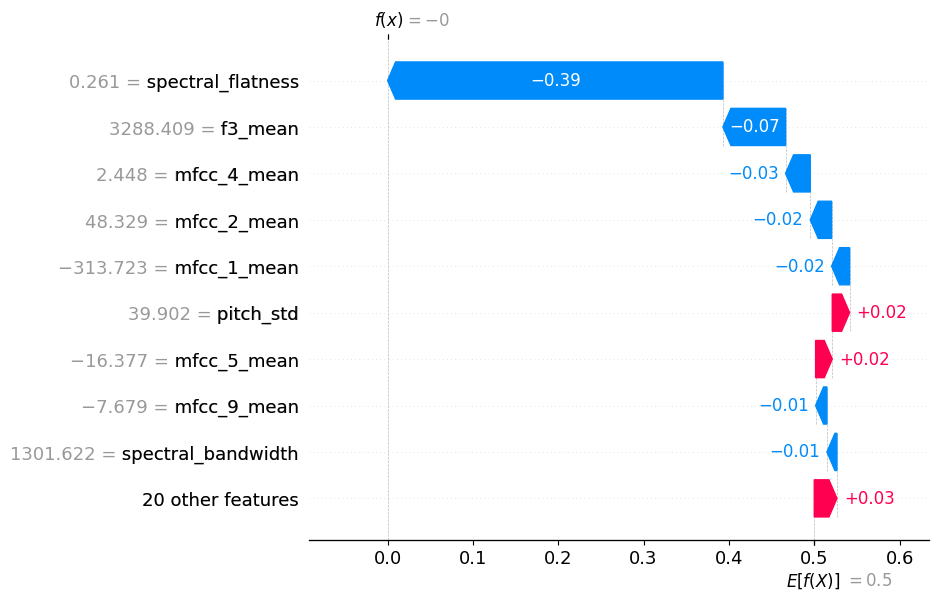

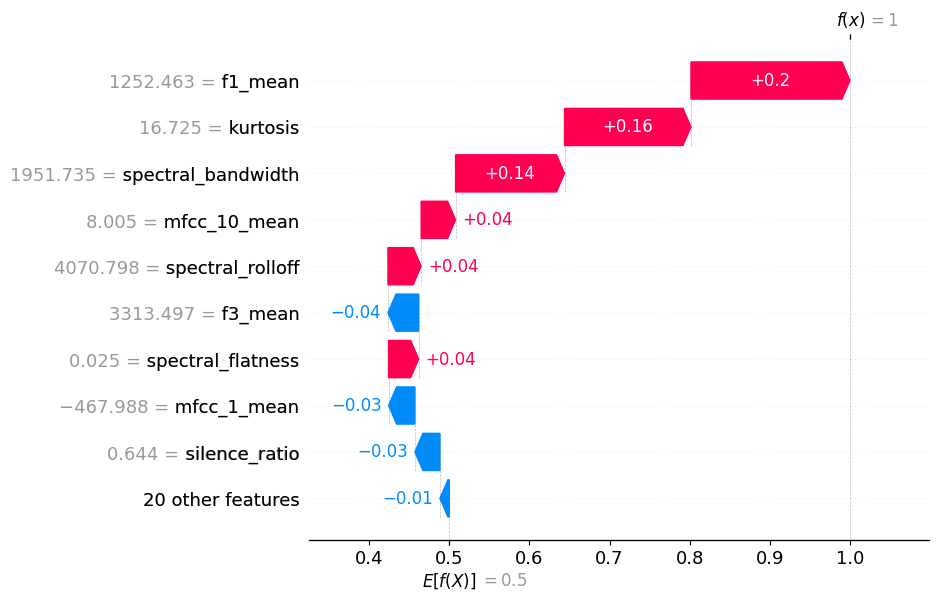

In [50]:
funciones.explica_shap(modelo=modelo_svm, X_train=X_train, X_test=df_esp, n_show=2, local=True)

### SHAP con audios en inglés

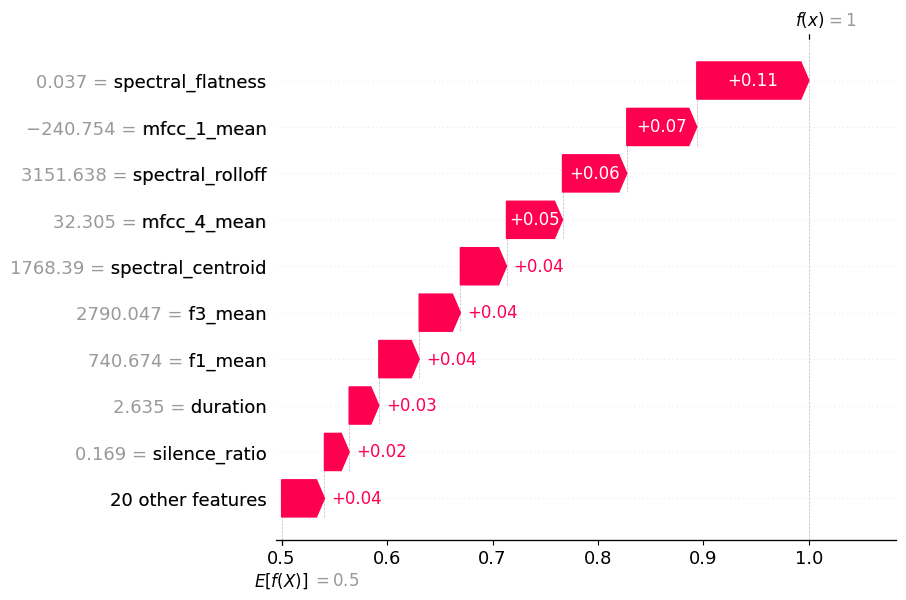

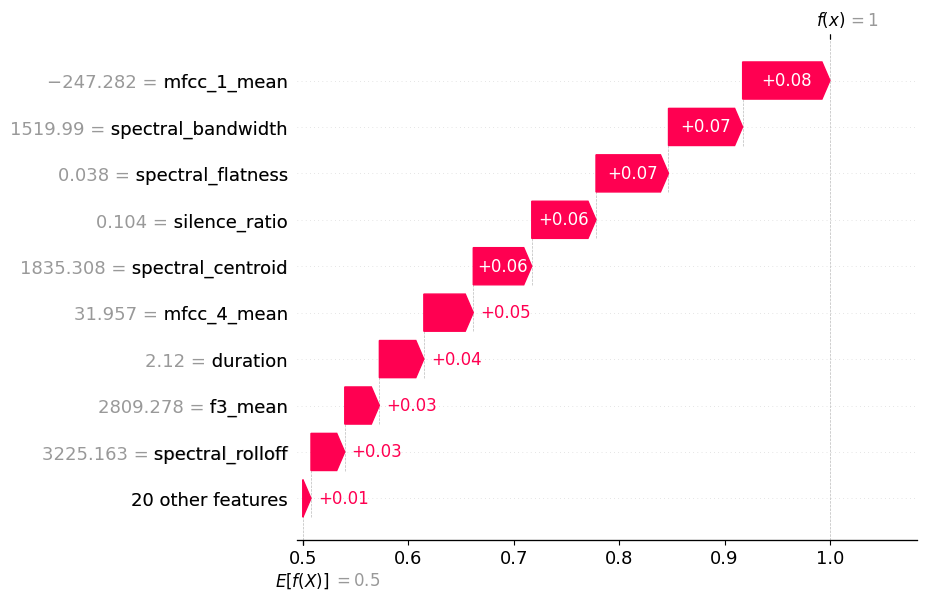

In [51]:
funciones.explica_shap(modelo=modelo_svm, X_train=X_train, X_test=df_eng, n_show=2, local=True)

### LIME

In [52]:
html = funciones.explica_lime(modelo=modelo_svm, columnas=X_train.columns, X_train=X_train, X_test=df_esp)

display(html)

c:\Users\Jorge\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


# K-NN

In [ ]:
df_esp_scaled_knn = scaler_knn.transform(df_esp)

y_pred_knn = modelo_knn.predict(df_esp_scaled_knn)
y_pred_proba_knn = modelo_knn.predict_proba(df_esp_scaled_knn)
print("Predicciones KNN:", y_pred_knn)
print("Probabilidades KNN:", y_pred_proba_knn)

# Regresión Logística

In [ ]:
df_esp_scaled_lr = scaler_lr.transform(df_esp)

y_pred_lr = modelo_lr.predict(df_esp_scaled_lr)
y_pred_proba_lr = modelo_lr.predict_proba(df_esp_scaled_lr)
print("Predicciones LR:", y_pred_lr)
print("Probabilidades LR:", y_pred_proba_lr)

# WAV2VEC2

Cosas que necesita el modelo

In [3]:
import pandas as pd

import tensorflow as tf

from transformers import (
    Wav2Vec2FeatureExtractor,
    Wav2Vec2ForSequenceClassification,
)
import os
    
import funciones_wav2vec2

## Generar predicciones

In [4]:
base = os.getcwd()

model = Wav2Vec2ForSequenceClassification.from_pretrained(
    os.path.join(base,"Iván\wav2vec2-deepfake-final") # Poner ruta donde esté el modelo
)
model.eval()

feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained(
    os.path.join(base,"Iván//wav2vec2-deepfake-final") # Poner ruta donde esté el modelo
)

for audio in audios:
    funciones_wav2vec2.generar_predicciones(model, feature_extractor, audio)

Loading weights:   0%|          | 0/215 [00:00<?, ?it/s]


nombre = español_generado
Salida del modelo = tensor([[ 0.5250, -0.5362]])
score = 0.2570866346359253

nombre = español_real
Salida del modelo = tensor([[-0.3412,  0.3625]])
score = 0.6690034866333008

nombre = ingles_generado
Salida del modelo = tensor([[-0.3787,  0.4049]])
score = 0.6864721775054932

nombre = ingles_natural
Salida del modelo = tensor([[ 0.5077, -0.5218]])
score = 0.26318100094795227


## Generar explicaciones

100%|██████████| 200/200 [00:08<00:00, 23.33it/s]


c:\Users\ivire\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\backend.py:452: UserWarning: `tf.keras.backend.set_learning_phase` is deprecated and will be removed after 2020-10-11. To update it, simply pass a True/False value to the `training` argument of the `__call__` method of your layer or model.
  warnings.warn(


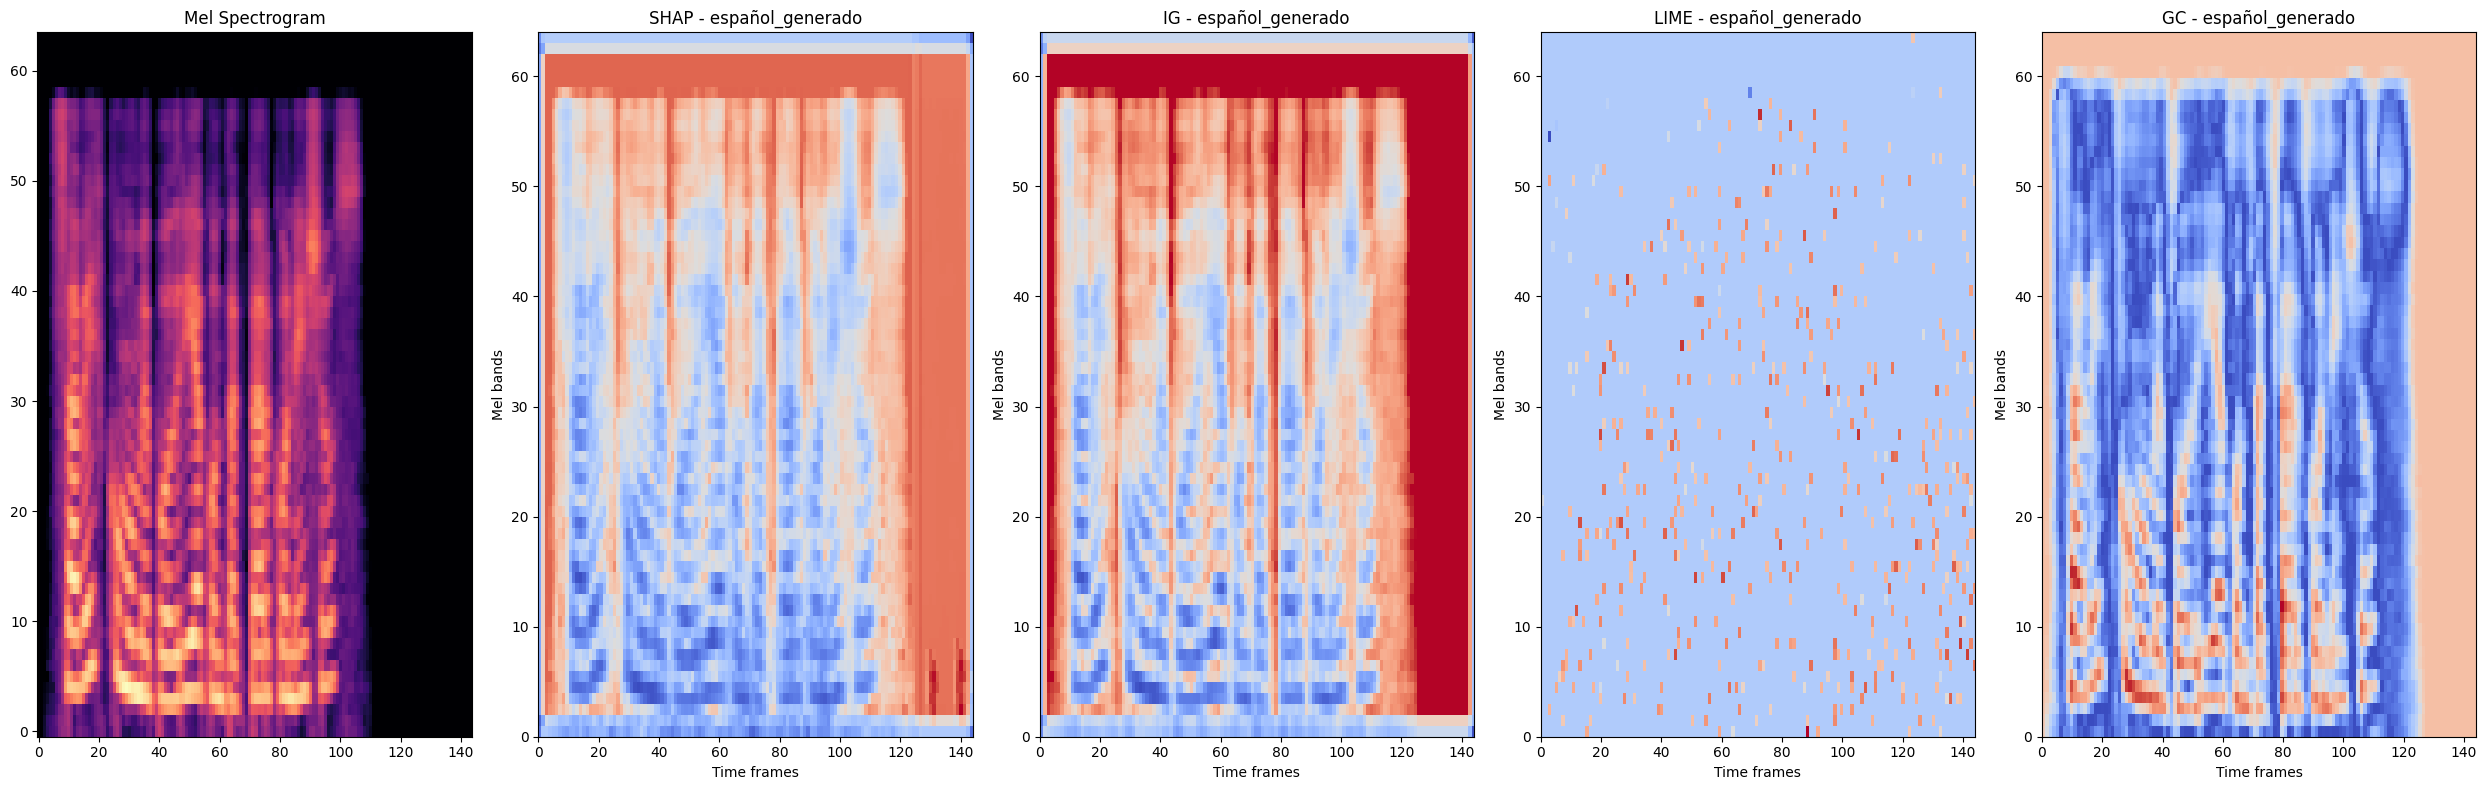

c:\Users\ivire\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\backend.py:452: UserWarning: `tf.keras.backend.set_learning_phase` is deprecated and will be removed after 2020-10-11. To update it, simply pass a True/False value to the `training` argument of the `__call__` method of your layer or model.
  warnings.warn(


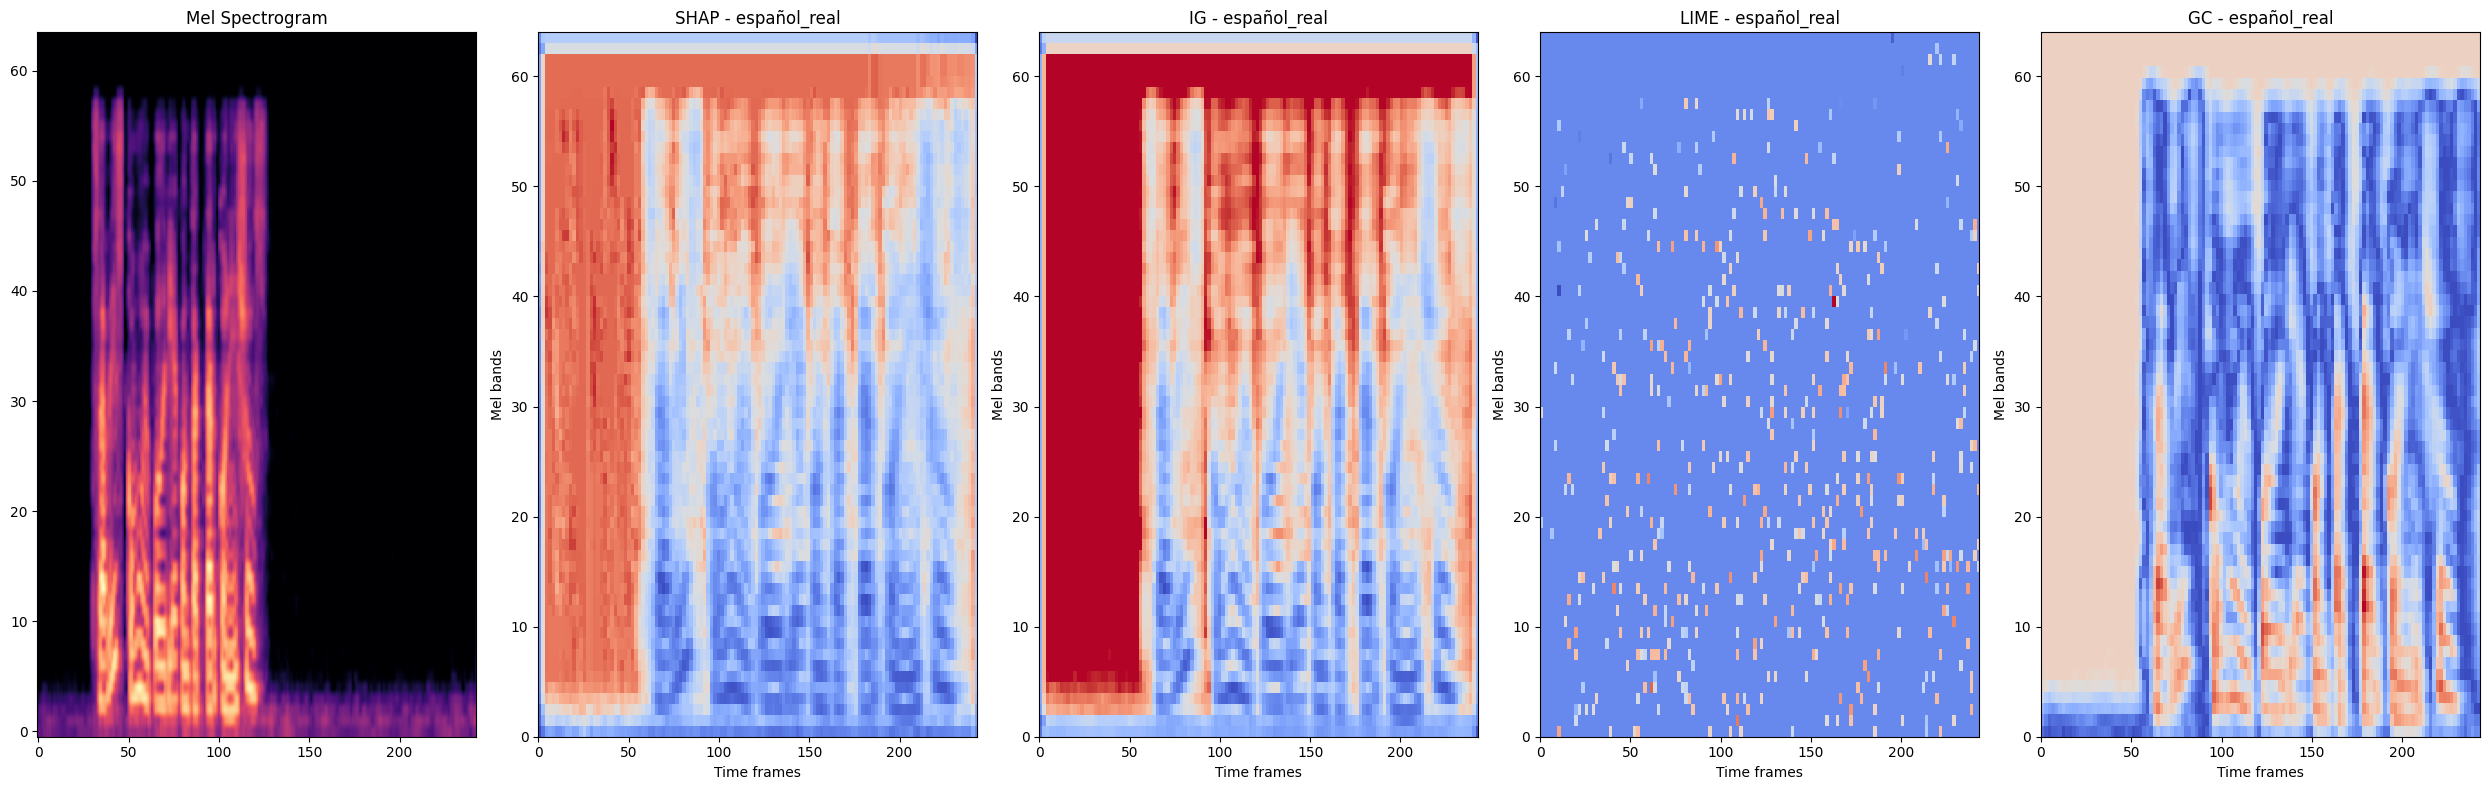

c:\Users\ivire\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\backend.py:452: UserWarning: `tf.keras.backend.set_learning_phase` is deprecated and will be removed after 2020-10-11. To update it, simply pass a True/False value to the `training` argument of the `__call__` method of your layer or model.
  warnings.warn(


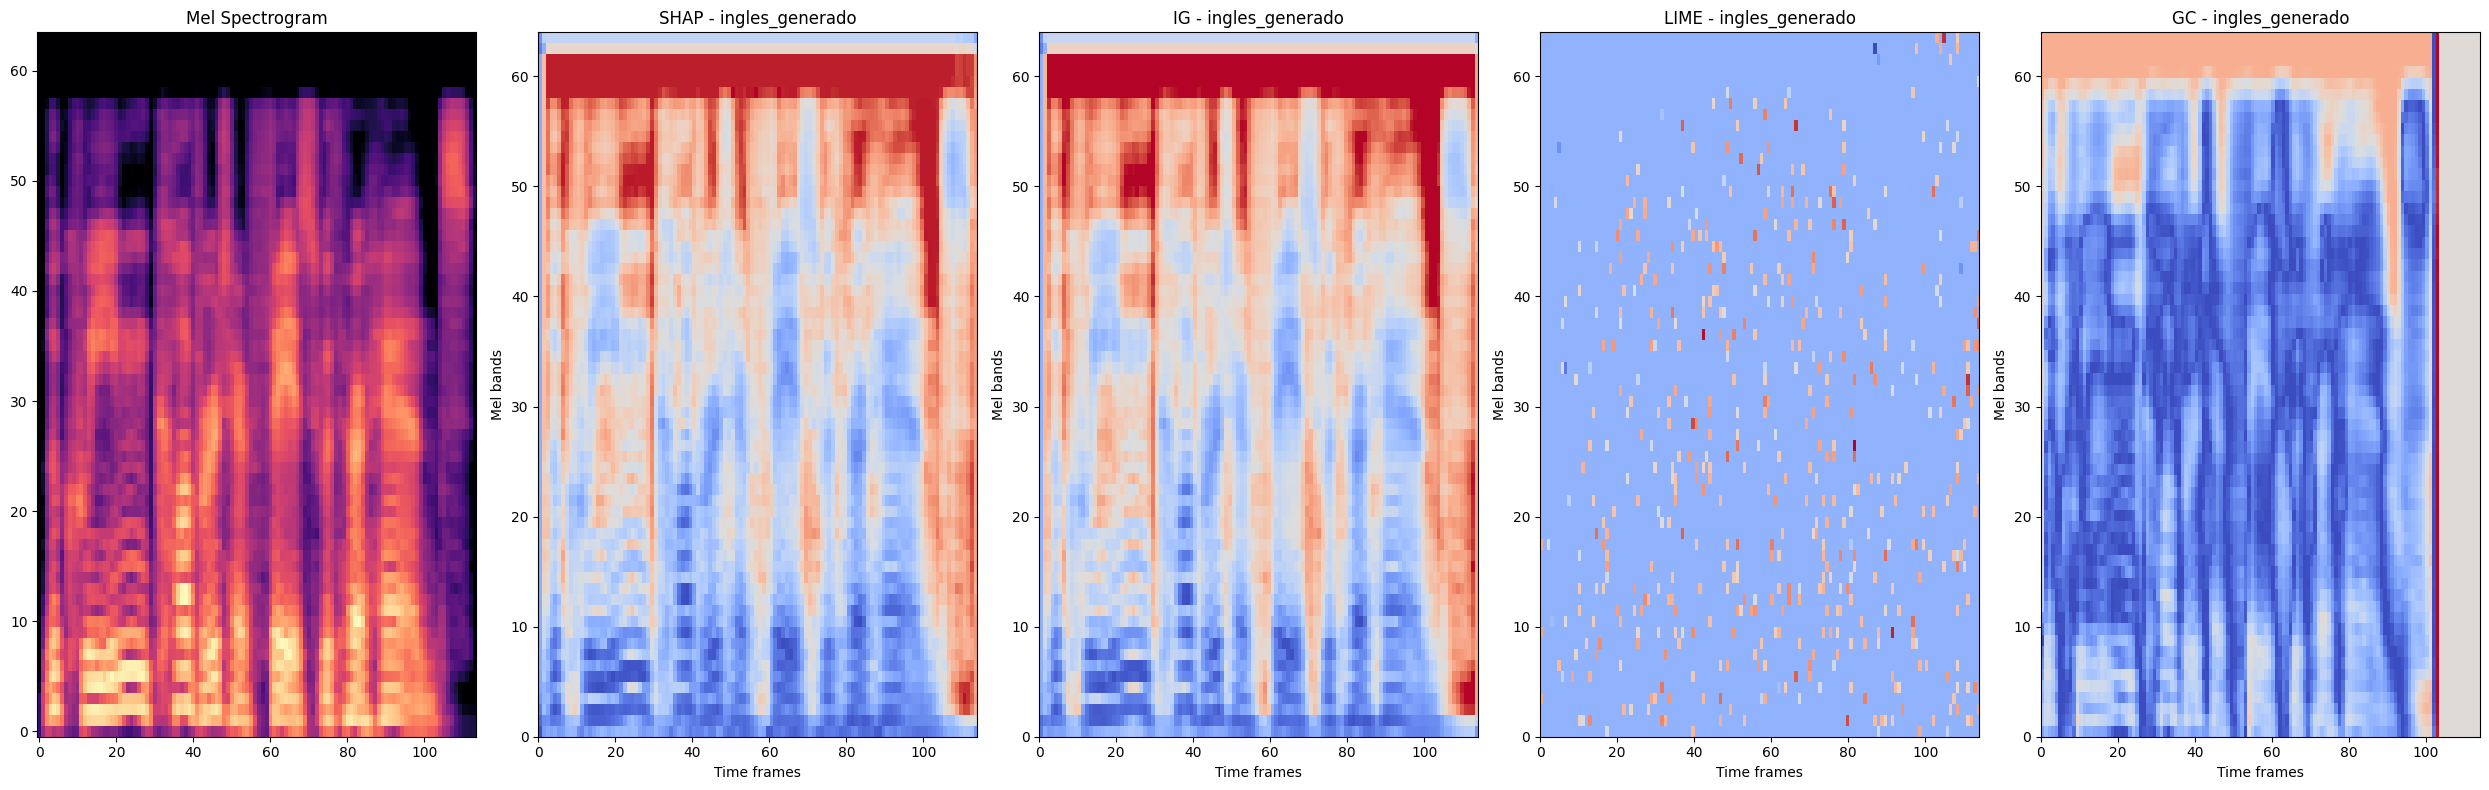

c:\Users\ivire\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\backend.py:452: UserWarning: `tf.keras.backend.set_learning_phase` is deprecated and will be removed after 2020-10-11. To update it, simply pass a True/False value to the `training` argument of the `__call__` method of your layer or model.
  warnings.warn(


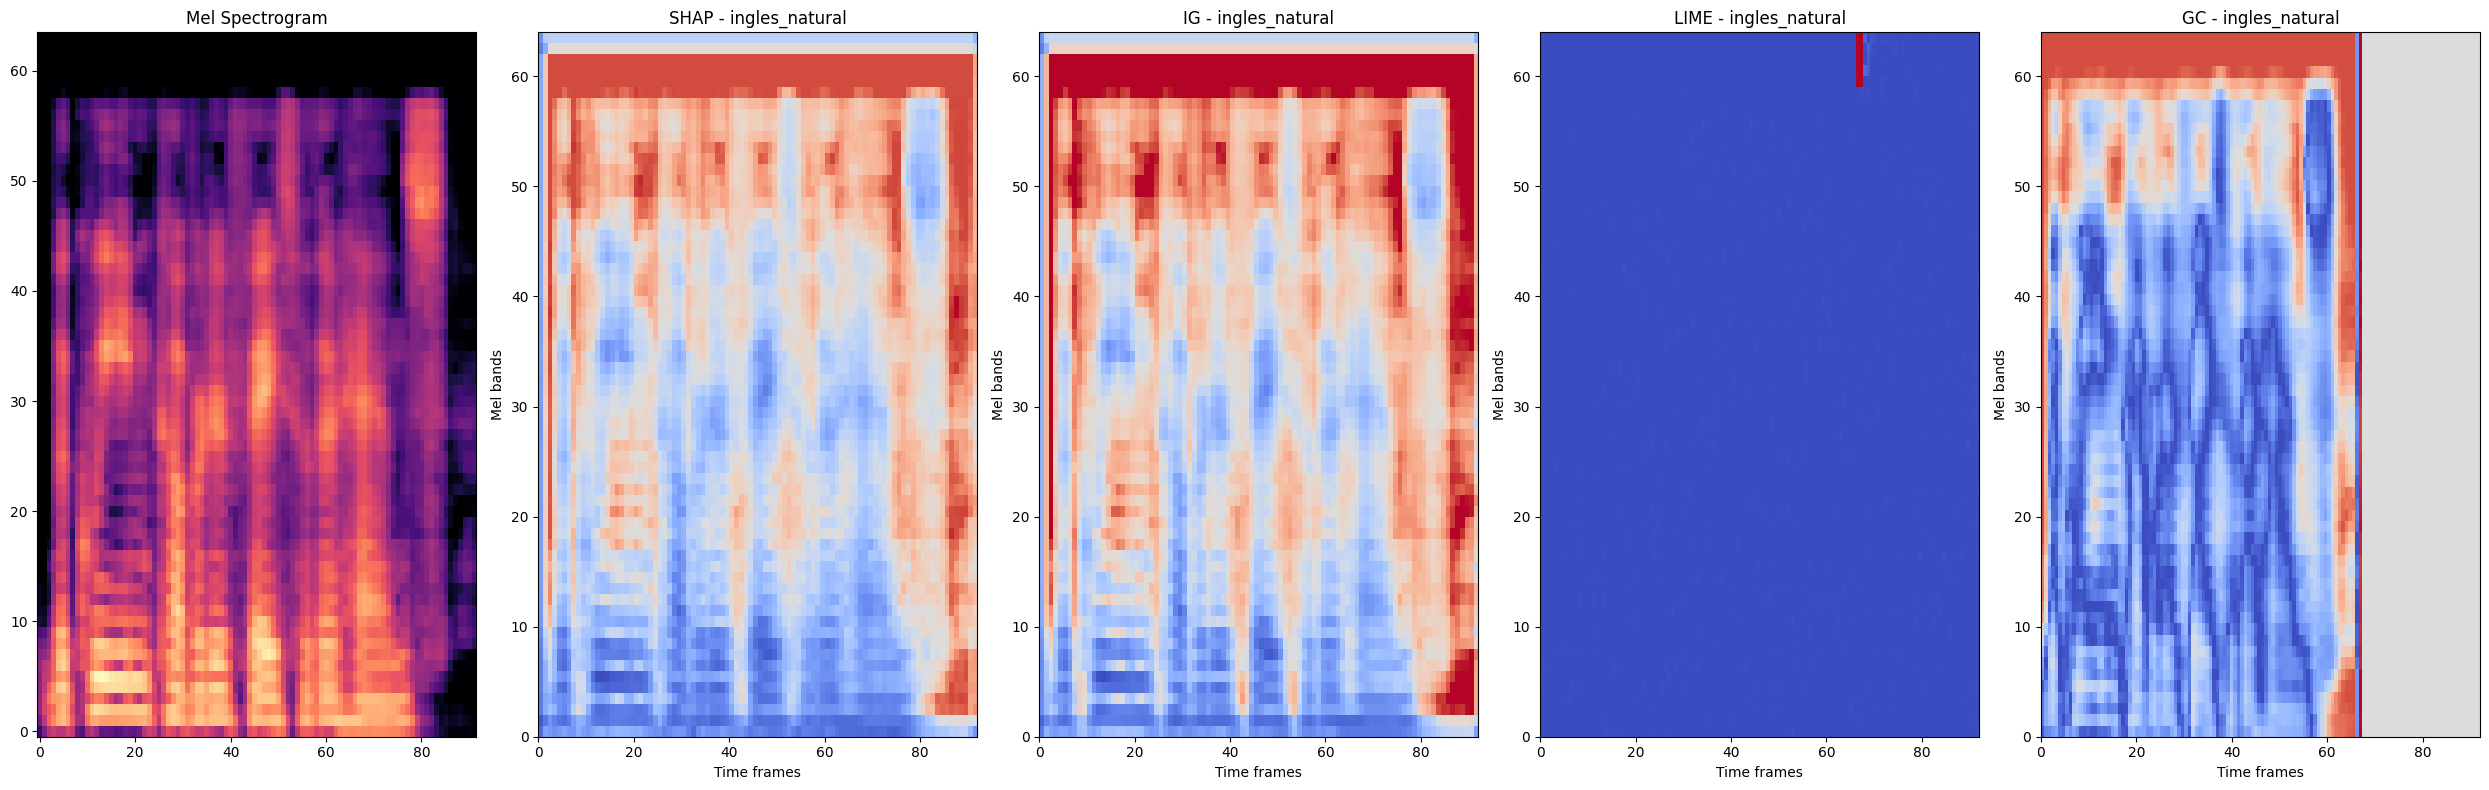

In [5]:
base = os.getcwd()


df_train = pd.read_csv("datos_entrenamiento_espectrogramas.csv")
X_tensor = funciones_wav2vec2.preprocesamiento(df_train,base)
y = df_train["salida_wav2vec2"]
y_tensor = tf.convert_to_tensor(y, dtype=tf.float32)

model_espectrogramas = funciones_wav2vec2.build_surrogate()
model_espectrogramas.fit(X_tensor,y_tensor,epochs=50,batch_size=4,verbose=0)

for audio in audios:
    funciones_wav2vec2.mostrar_graficas(model_espectrogramas,audio,X_tensor)

## AASIST

{'logits': tensor([[ 3.9811, -4.0616]]), 'score_bonafide': -4.06155252456665, 'prob_bonafide': 0.0003213507297914475, 'pred_clase': 'spoof'}


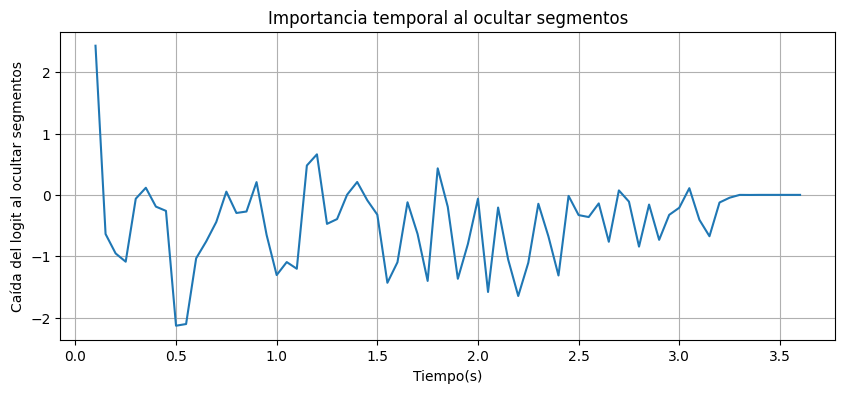

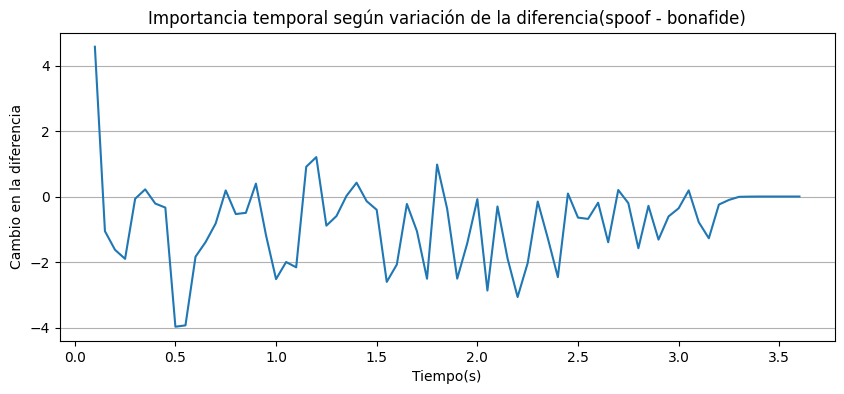

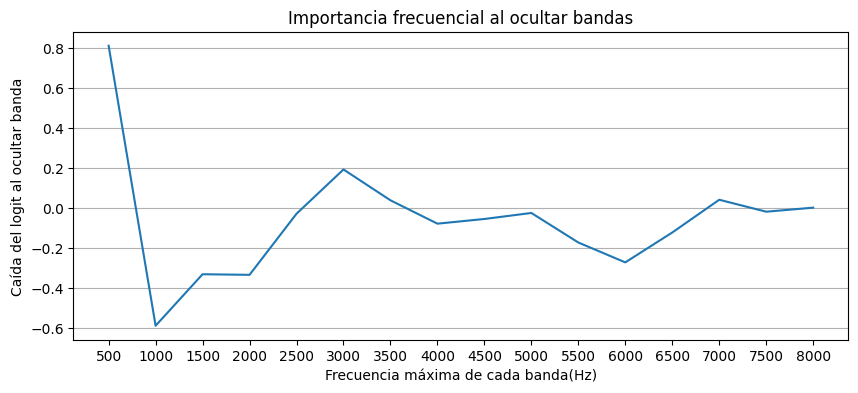

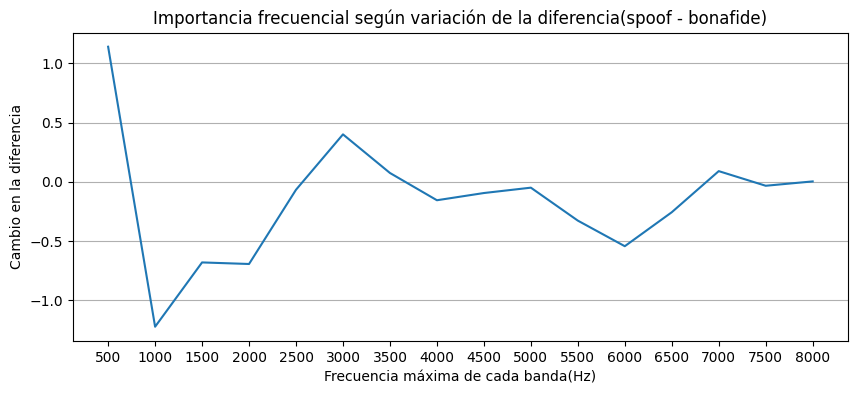

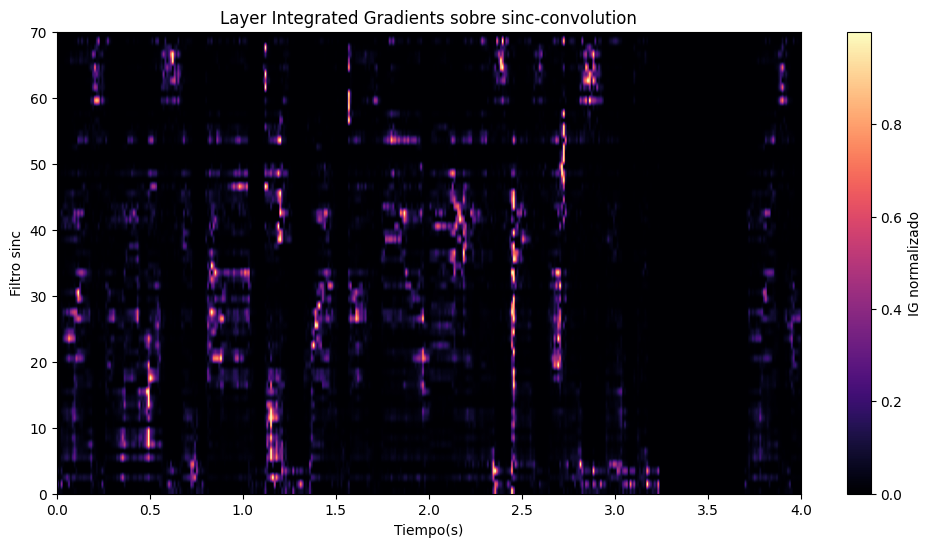

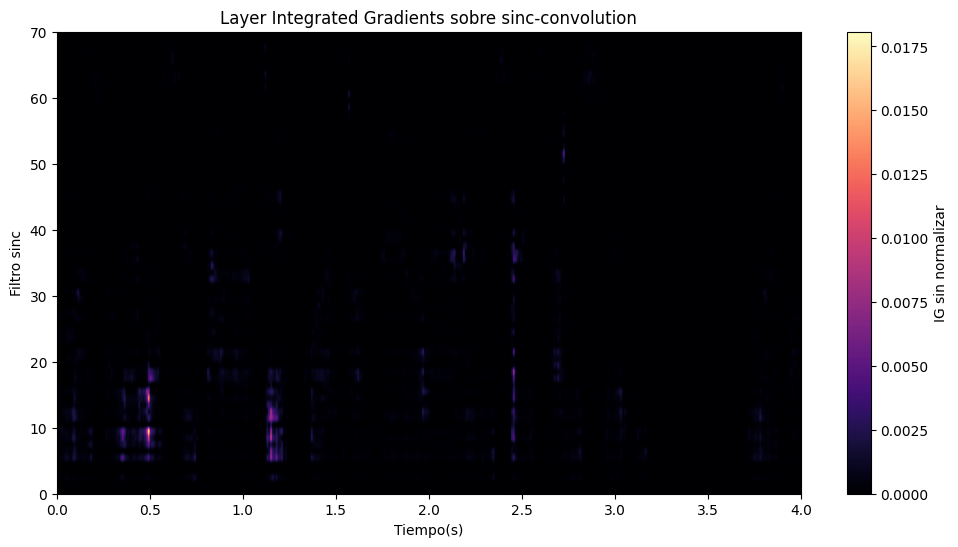

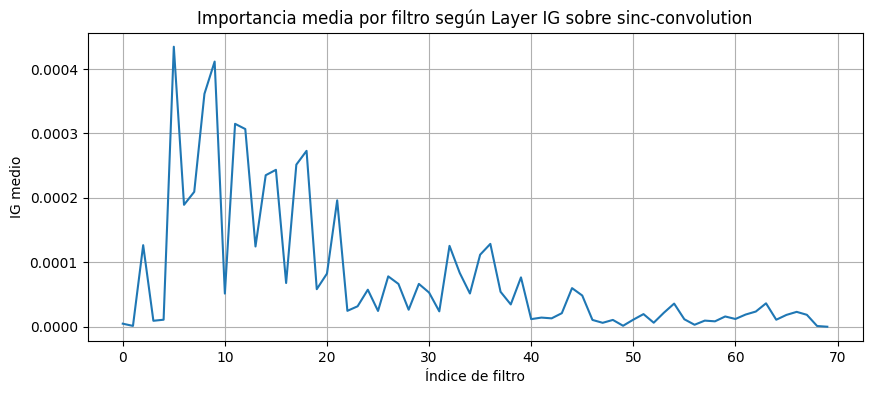

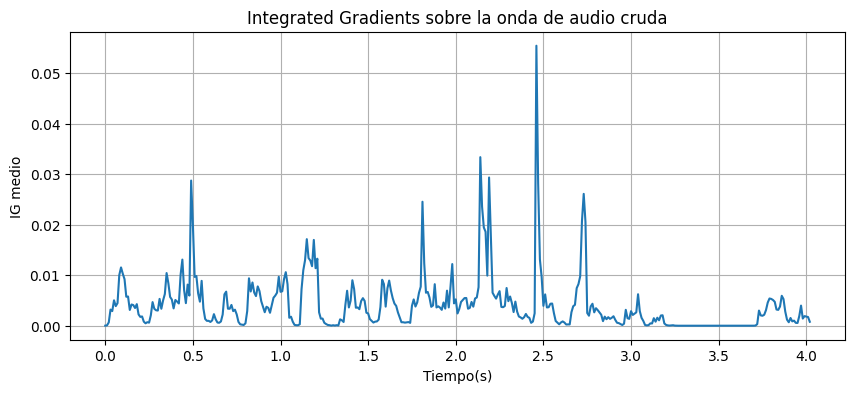

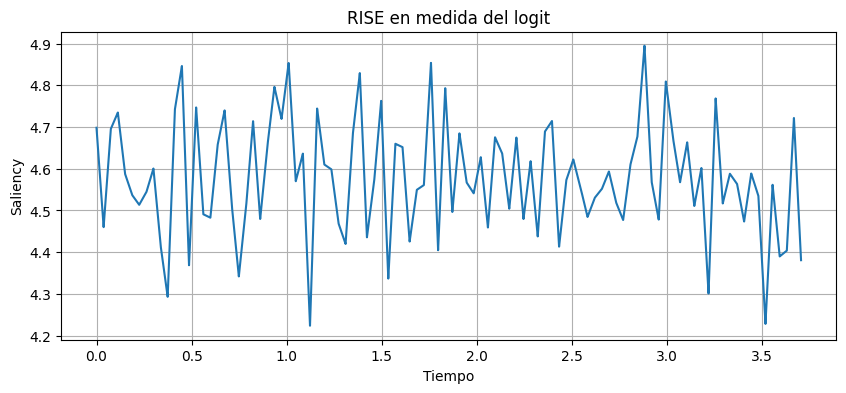

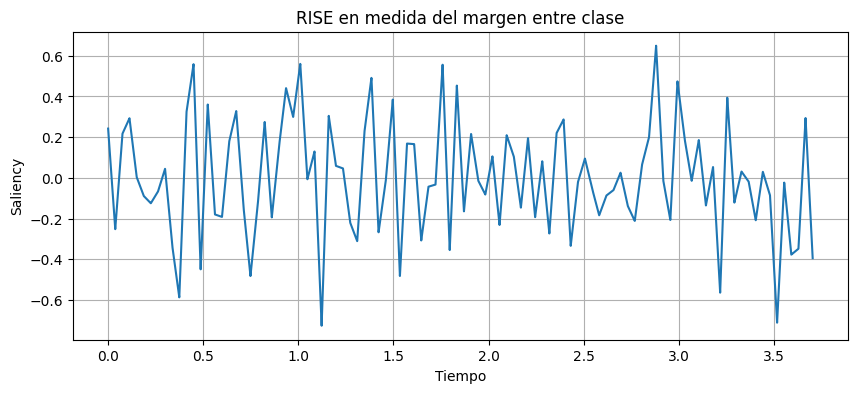

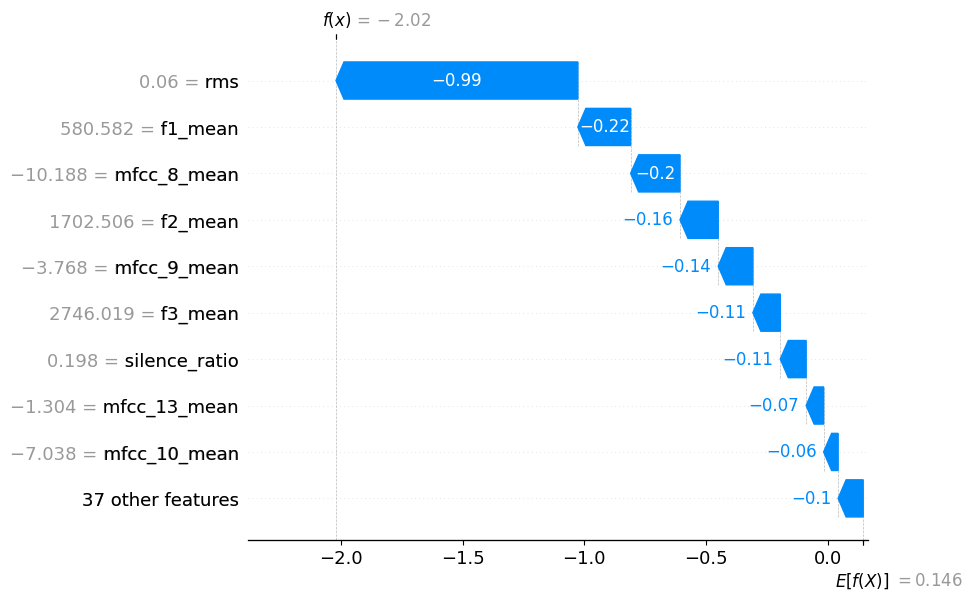

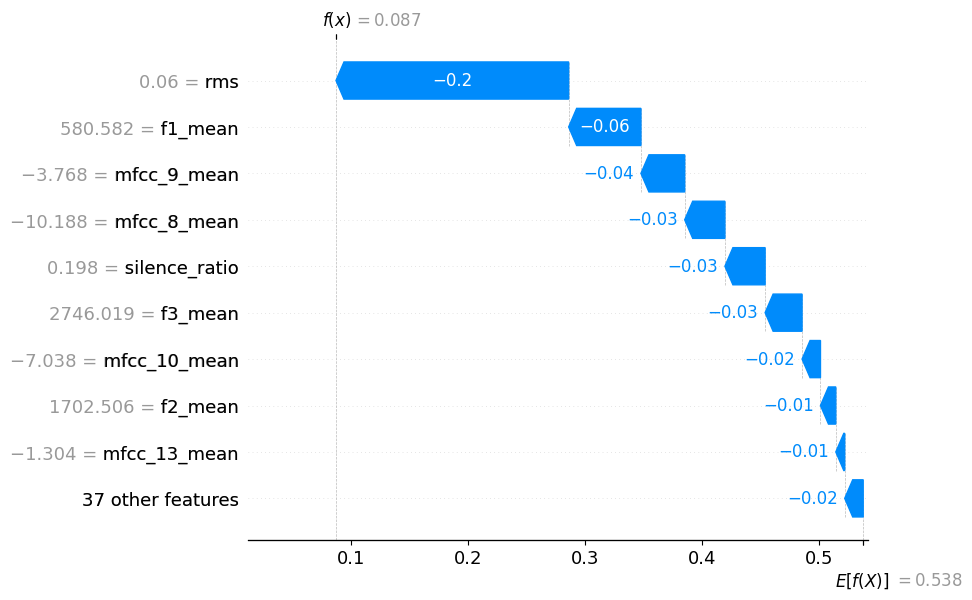

In [ ]:
sys.path.insert(0, str((Path.cwd() / "German").resolve()))
from funciones_aasist import *
from AASIST import Model

model = torch.load("German/aasist_full.pt", map_location="cpu", weights_only=False)
model.eval()

audio = r"C:\TFG\Datasets\Propio\Generado\Español\E_1_G.wav"
res = score_audio(audio, model) 
print(res)
aplicar_XAI(wav_path = audio, model = model, df = df) 